In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [51]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [52]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), 
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.net(x)

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, method='max', l=None, alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.method = method
        self.bias = bias

        self.w = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        if bias:
            self.b = nn.Parameter(torch.randn(output_size))
            if method == 'max-plus-min' or method == 'dep':
                self.b2 = nn.Parameter(torch.randn(output_size))
        if method == 'dep':
            self.w2 = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
            if l == None:
                self.l = nn.Parameter(torch.rand(output_size))
            else:
                self.l = l + torch.zeros(output_size).to(device)

    def forward(self, x):
        x = x.unsqueeze(1) 
        if self.method == 'max':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.method == 'min':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.min(x, dim=2)
        elif self.method == 'max-plus-min':
            x_max = x + self.w
            x_min = x + self.w
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            x = x_max + x_min
        elif self.method == 'dep':
            x_max = x + self.w
            x_min = x + self.w2
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x_max.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x_min.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            l = self.l.view(1,-1)
            l = torch.clamp(l, 0, 1)
            x = l * x_max + (1-l) * x_min
        return x

class LinAct(nn.Module):
    def __init__(self, size, method="simple"):
        super(LinAct, self).__init__()
        self.size = size
        self.method = method
        if method == "simple":
            self.a = nn.Parameter(torch.randn(size) / 3.46)
            # self.a = nn.Parameter(torch.rand(size)-0.5)
        else:
            tmp = nn.Linear(size, size, bias = False).weight.detach()
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.V = torch.tensor(Vh).t().to(device)
            self.a = torch.zeros(size).to(device)
            self.a[:S.shape[0]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)

    def forward(self, x):
        if self.method == "simple":
            x = x * self.a.view(1, -1).repeat(x.size(0), 1)
        else:
            Smat = torch.diag(self.a)
            tmp = self.U @ Smat @ self.V.t()
            x = torch.mm(x, tmp.t())
        return x

class MPM(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super(MPM, self).__init__()
        self.net = nn.Sequential(
            MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=1),
            LinAct(hidden_size),
            MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1),
            LinAct(hidden_size),
            MorphologicalLayer(hidden_size, output_size, method='max-plus-min', alpha=1)
        )
    
    def forward(self, x):
        return self.net(x)
    
class MPM_noact(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super(MPM_noact, self).__init__()
        self.net = nn.Sequential(
            MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=1),
            MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1),
            MorphologicalLayer(hidden_size, output_size, method='max-plus-min', alpha=1)
        )
    
    def forward(self, x):
        return self.net(x)

In [53]:
# Generate sine wave data dynamically
def generate_sine_wave(batch_size, x_range=(-2 * np.pi, 2 * np.pi)):
    x = np.random.uniform(x_range[0], x_range[1], batch_size)
    y = 6 * np.sin(x) 
    noise = np.random.normal(0, 0.1, batch_size)  
    y_noisy = y + noise 
    return x, y_noisy

def generate_parabola(batch_size, x_range=(-2 * np.pi, 2 * np.pi)):
    x = np.random.uniform(x_range[0], x_range[1], batch_size) 
    y = np.sin(x)  # Sine wave values
    y = x ** 2
    noise = np.random.normal(0, 0.1, batch_size)  
    y_noisy = y + noise 
    return x, y_noisy

def generate_line(batch_size, x_range=(-2 * np.pi, 2 * np.pi)):
    x = np.random.uniform(x_range[0], x_range[1], batch_size) 
    y = np.sin(x)  # Sine wave values
    y = 20 * x
    noise = np.random.normal(0, 0.1, batch_size)  
    y_noisy = y + noise 
    return x, y_noisy

In [54]:
def train(mlp, mpm, mpm_noact, criterion, optimizer, generate_function, epochs, batch_size, x_range):
    # Training loop
    for epoch in range(epochs):
        mlp.train()
        mpm.train()
        mpm_noact.train()
        total_loss_mlp = 0
        total_loss_mpm = 0
        total_loss_mpm_noact = 0
        epoch_noisy_data = {"x": [], "y": []}  # Store noisy data for visualization
        
        # Generate training data dynamically for each batch
        for _ in range(100):  # Assume 100 batches per epoch
            x_train, y_train = generate_function(batch_size, x_range)
            
            # Accumulate noisy data for plotting
            epoch_noisy_data["x"].extend(x_train)
            epoch_noisy_data["y"].extend(y_train)
            
            x_train = torch.tensor(x_train, dtype=torch.float32).view(-1, 1).to(device)
            y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
            
            # Forward pass
            predictions = mlp(x_train)
            loss = criterion(predictions, y_train)
            
            # Backward pass
            optimizer[0].zero_grad()
            loss.backward()
            optimizer[0].step()
            
            total_loss_mlp += loss.item()

            # Forward pass
            predictions = mpm(x_train)
            loss = criterion(predictions, y_train)
            
            # Backward pass
            optimizer[1].zero_grad()
            loss.backward()
            optimizer[1].step()
            
            total_loss_mpm += loss.item()

            # Forward pass
            predictions = mpm_noact(x_train)
            loss = criterion(predictions, y_train)
            
            # Backward pass
            optimizer[2].zero_grad()
            loss.backward()
            optimizer[2].step()
            
            total_loss_mpm_noact += loss.item()
        
        # Print epoch loss
        print(f"Epoch {epoch+1}/{epochs}, Loss: MLP: {total_loss_mlp / 100:.4f}, MPM: {total_loss_mpm / 100:.4f}, MPM_noact: {total_loss_mpm_noact / 100:.4f}")

    return epoch_noisy_data

In [57]:
# Hyperparameters
epochs = 50
batch_size = 128
learning_rate = 0.001
x_range = (-2 * np.pi, 2 * np.pi)

# Prepare model, loss function, and optimizer
mlp = MLP().to(device)
mpm = MPM().to(device)
mpm_noact = MPM_noact().to(device)
criterion = nn.MSELoss()
optimizer = [optim.Adam(mlp.parameters(), lr=learning_rate), 
             optim.Adam(mpm.parameters(), lr=learning_rate), 
             optim.Adam(mpm_noact.parameters(), lr=learning_rate)
]

epoch_noisy_data = train(mlp, mpm, mpm_noact, criterion, optimizer, generate_sine_wave, epochs, batch_size, x_range)

# Visualization at the end of the epoch
mlp.eval()
x_vis = torch.linspace(x_range[0], x_range[1], 1000).view(-1, 1).to(device)
y_vis = 6*torch.sin(x_vis).to(device)
y_pred_mlp = mlp(x_vis).detach()
y_pred_mpm = mpm(x_vis).detach()
y_pred_mpm_noact = mpm_noact(x_vis).detach()

Epoch 1/50, Loss: MLP: 10.4071, MPM: 17.2214, MPM_noact: 147.4200
Epoch 2/50, Loss: MLP: 4.7327, MPM: 15.0732, MPM_noact: 135.2369
Epoch 3/50, Loss: MLP: 4.2600, MPM: 13.5616, MPM_noact: 123.3490
Epoch 4/50, Loss: MLP: 3.7772, MPM: 11.7496, MPM_noact: 114.1835
Epoch 5/50, Loss: MLP: 3.3963, MPM: 9.9707, MPM_noact: 105.5624
Epoch 6/50, Loss: MLP: 3.0342, MPM: 8.1787, MPM_noact: 98.2221
Epoch 7/50, Loss: MLP: 2.6445, MPM: 6.6190, MPM_noact: 92.7037
Epoch 8/50, Loss: MLP: 2.2191, MPM: 5.1952, MPM_noact: 87.8624
Epoch 9/50, Loss: MLP: 1.8042, MPM: 4.0735, MPM_noact: 83.1569
Epoch 10/50, Loss: MLP: 1.4466, MPM: 3.1176, MPM_noact: 78.5300
Epoch 11/50, Loss: MLP: 1.1696, MPM: 2.3738, MPM_noact: 73.6132
Epoch 12/50, Loss: MLP: 0.8664, MPM: 1.8333, MPM_noact: 71.6948
Epoch 13/50, Loss: MLP: 0.6936, MPM: 1.4352, MPM_noact: 68.4866
Epoch 14/50, Loss: MLP: 0.5087, MPM: 1.1541, MPM_noact: 65.4689
Epoch 15/50, Loss: MLP: 0.3540, MPM: 0.9291, MPM_noact: 61.3433
Epoch 16/50, Loss: MLP: 0.2653, MPM: 0.

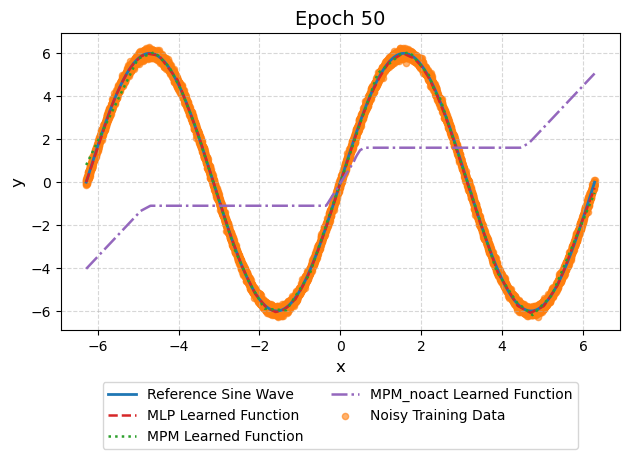

In [ ]:
plt.figure()

# Plot the reference function
plt.plot(x_vis.cpu().numpy(), y_vis.cpu().numpy(), label="Reference Sine Wave", color="#1f77b4", linewidth=2)

# Plot the learned functions with different styles and colors
plt.plot(x_vis.cpu().numpy(), y_pred_mlp.cpu().numpy(), label="MLP Learned Function", color="#d62728", linestyle="--", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm.cpu().numpy(), label="MPM Learned Function", color="#2ca02c", linestyle=":", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm_noact.cpu().numpy(), label="MPM_noact Learned Function", color="#9467bd", linestyle="-.", linewidth=1.8)

# Plot the noisy data
plt.scatter(epoch_noisy_data["x"], epoch_noisy_data["y"], label="Noisy Training Data", color="#ff7f0e", alpha=0.6, s=20)

# Legend beneath the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.title(f"Epoch {epochs}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"regression1.png", format='png', dpi=1000)
plt.show()


In [63]:
# Hyperparameters
epochs = 50
batch_size = 128
learning_rate = 0.001
x_range = (-2 * np.pi, 2 * np.pi)

# Prepare model, loss function, and optimizer
mlp = MLP().to(device)
mpm = MPM().to(device)
mpm_noact = MPM_noact().to(device)
criterion = nn.MSELoss()
optimizer = [optim.Adam(mlp.parameters(), lr=learning_rate), 
             optim.Adam(mpm.parameters(), lr=learning_rate), 
             optim.Adam(mpm_noact.parameters(), lr=learning_rate)
]

epoch_noisy_data = train(mlp, mpm, mpm_noact, criterion, optimizer, generate_parabola, epochs, batch_size, x_range)

# Visualization at the end of the epoch
mlp.eval()
x_vis = torch.linspace(x_range[0], x_range[1], 1000).view(-1, 1).to(device)
y_vis = torch.pow(x_vis, 2).to(device)
y_pred_mlp = mlp(x_vis).detach()
y_pred_mpm = mpm(x_vis).detach()
y_pred_mpm_noact = mpm_noact(x_vis).detach()

Epoch 1/50, Loss: MLP: 84.1067, MPM: 288.1814, MPM_noact: 363.9172
Epoch 2/50, Loss: MLP: 11.2878, MPM: 250.2481, MPM_noact: 349.7019
Epoch 3/50, Loss: MLP: 5.0654, MPM: 198.5525, MPM_noact: 327.2101
Epoch 4/50, Loss: MLP: 3.8782, MPM: 155.8601, MPM_noact: 319.7708
Epoch 5/50, Loss: MLP: 2.6492, MPM: 117.1444, MPM_noact: 313.8635
Epoch 6/50, Loss: MLP: 1.6750, MPM: 85.1211, MPM_noact: 294.2639
Epoch 7/50, Loss: MLP: 0.9170, MPM: 63.2101, MPM_noact: 276.2565
Epoch 8/50, Loss: MLP: 0.5329, MPM: 49.9901, MPM_noact: 278.9611
Epoch 9/50, Loss: MLP: 0.3171, MPM: 40.2608, MPM_noact: 266.8216
Epoch 10/50, Loss: MLP: 0.1996, MPM: 31.1667, MPM_noact: 247.2967
Epoch 11/50, Loss: MLP: 0.1401, MPM: 26.6518, MPM_noact: 244.7355
Epoch 12/50, Loss: MLP: 0.0983, MPM: 21.1504, MPM_noact: 225.8772
Epoch 13/50, Loss: MLP: 0.0737, MPM: 17.5475, MPM_noact: 226.5118
Epoch 14/50, Loss: MLP: 0.0588, MPM: 15.3936, MPM_noact: 218.2514
Epoch 15/50, Loss: MLP: 0.0448, MPM: 13.0706, MPM_noact: 196.4242
Epoch 16/50,

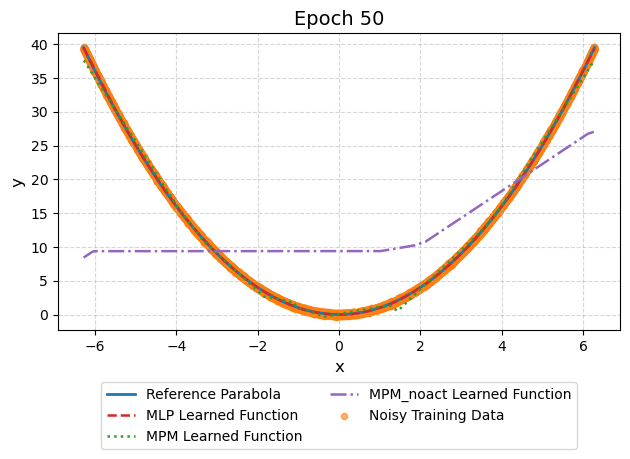

In [ ]:
plt.figure()

# Plot the reference function
plt.plot(x_vis.cpu().numpy(), y_vis.cpu().numpy(), label="Reference Parabola", color="#1f77b4", linewidth=2)

# Plot the learned functions with different styles and colors
plt.plot(x_vis.cpu().numpy(), y_pred_mlp.cpu().numpy(), label="MLP Learned Function", color="#d62728", linestyle="--", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm.cpu().numpy(), label="MPM Learned Function", color="#2ca02c", linestyle=":", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm_noact.cpu().numpy(), label="MPM_noact Learned Function", color="#9467bd", linestyle="-.", linewidth=1.8)

# Plot the noisy data
plt.scatter(epoch_noisy_data["x"], epoch_noisy_data["y"], label="Noisy Training Data", color="#ff7f0e", alpha=0.6, s=20)

# Legend beneath the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.title(f"Epoch {epochs}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"regression2.png", format='png', dpi=1000)
plt.show()


In [65]:
# Hyperparameters
epochs = 50
batch_size = 128
learning_rate = 0.001
x_range = (-2 * np.pi, 2 * np.pi)

# Prepare model, loss function, and optimizer
mlp = MLP().to(device)
mpm = MPM().to(device)
mpm_noact = MPM_noact().to(device)
criterion = nn.MSELoss()
optimizer = [optim.Adam(mlp.parameters(), lr=learning_rate), 
             optim.Adam(mpm.parameters(), lr=learning_rate), 
             optim.Adam(mpm_noact.parameters(), lr=learning_rate)
]

epoch_noisy_data = train(mlp, mpm, mpm_noact, criterion, optimizer, generate_line, epochs, batch_size, x_range)

# Visualization at the end of the epoch
mlp.eval()
x_vis = torch.linspace(x_range[0], x_range[1], 1000).view(-1, 1).to(device)
y_vis = (20 * x_vis).to(device)
y_pred_mlp = mlp(x_vis).detach()
y_pred_mpm = mpm(x_vis).detach()
y_pred_mpm_noact = mpm_noact(x_vis).detach()

Epoch 1/50, Loss: MLP: 2557.8970, MPM: 5162.6037, MPM_noact: 3796.3033
Epoch 2/50, Loss: MLP: 7.6634, MPM: 4974.3555, MPM_noact: 3722.5032
Epoch 3/50, Loss: MLP: 0.5424, MPM: 4780.0706, MPM_noact: 3695.7451
Epoch 4/50, Loss: MLP: 0.1146, MPM: 4445.2416, MPM_noact: 3572.2912
Epoch 5/50, Loss: MLP: 0.0641, MPM: 4145.4436, MPM_noact: 3540.2421
Epoch 6/50, Loss: MLP: 0.0523, MPM: 3707.1689, MPM_noact: 3451.1648
Epoch 7/50, Loss: MLP: 0.0437, MPM: 3235.9349, MPM_noact: 3384.6348
Epoch 8/50, Loss: MLP: 0.0382, MPM: 2785.7914, MPM_noact: 3347.7781
Epoch 9/50, Loss: MLP: 0.0320, MPM: 2321.0923, MPM_noact: 3291.3765
Epoch 10/50, Loss: MLP: 0.0283, MPM: 1852.1383, MPM_noact: 3171.5567
Epoch 11/50, Loss: MLP: 0.0243, MPM: 1512.0431, MPM_noact: 3182.3464
Epoch 12/50, Loss: MLP: 0.0211, MPM: 1183.6931, MPM_noact: 3140.4364
Epoch 13/50, Loss: MLP: 0.0192, MPM: 893.6571, MPM_noact: 3062.5405
Epoch 14/50, Loss: MLP: 0.0181, MPM: 659.9034, MPM_noact: 3001.1532
Epoch 15/50, Loss: MLP: 0.0175, MPM: 486.9

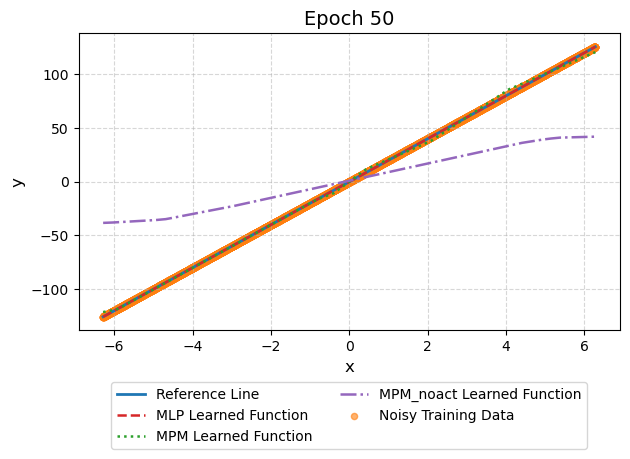

In [ ]:
plt.figure()

# Plot the reference function
plt.plot(x_vis.cpu().numpy(), y_vis.cpu().numpy(), label="Reference Line", color="#1f77b4", linewidth=2)

# Plot the learned functions with different styles and colors
plt.plot(x_vis.cpu().numpy(), y_pred_mlp.cpu().numpy(), label="MLP Learned Function", color="#d62728", linestyle="--", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm.cpu().numpy(), label="MPM Learned Function", color="#2ca02c", linestyle=":", linewidth=1.8)
plt.plot(x_vis.cpu().numpy(), y_pred_mpm_noact.cpu().numpy(), label="MPM_noact Learned Function", color="#9467bd", linestyle="-.", linewidth=1.8)

# Plot the noisy data
plt.scatter(epoch_noisy_data["x"], epoch_noisy_data["y"], label="Noisy Training Data", color="#ff7f0e", alpha=0.6, s=20)

# Legend beneath the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.title(f"Epoch {epochs}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"regression3.png", format='png', dpi=1000)
plt.show()


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

device = 'cuda'

# Define the MLP model
class LP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(LP, self).__init__()
        self.net = nn.Linear(input_size, output_size)
        self.net.weight.data *= 0
    
    def forward(self, x):
        return self.net(x)

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, aggregate='max', alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.aggregate = aggregate
        self.bias = bias
        self.weight = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        self.b = nn.Parameter(torch.randn(output_size))

    def forward(self, x):
        x = x.unsqueeze(1)  # Reshape (batch, 1, input_size) to (batch, output_size, input_size)
        x = x + self.weight
        if self.bias:
            x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
        if self.aggregate == 'max':
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.aggregate == 'min':
            x, _ = torch.min(x, dim=2)
        else:
            x_max, _ = torch.max(x, dim=2)
            x_min, _ = torch.min(x, dim=2)
            x = x_max + x_min
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(MP, self).__init__()
        self.net = MorphologicalLayer(input_size, output_size, bias=False, aggregate='max', alpha=0, beta=0)

    def forward(self, x):
        return self.net(x)

# Define Data Generation Function
def generate_linear_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.dot(x, w)  # Project onto w
    return x, y

def generate_morphological_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.max(x + w, axis=1)  # Project onto w
    return x, y

# Hyperparameters
epochs = 1000
batch_size = 1
learning_rate = 0.1
d = 10  # Number of input dimensions
w = np.array([10 for _ in range(d)])  # Projection vector (Example: arbitrary choice)

# Prepare model, loss function, and optimizer
model = LP(d).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    model.train()

    x_train, y_train = generate_linear_data(batch_size, d, w)
    
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    
    # Forward pass
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print epoch loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item() / 100:.4f}, "
      f"weights: {model.net.weight.data.cpu().numpy().round(2)}, "
      f"mean: {model.net.weight.mean(dim=-1).mean(dim=-1).item():.2f}, "
      f"std: {model.net.weight.std(dim=-1).sum(dim=-1).item():.2f}")


Epoch 1/1000, Loss: 22.6633, weights: [[-0.1  0.1 -0.1 -0.1  0.1  0.1  0.1  0.1  0.1  0.1]], mean: 0.04, std: 0.10
Epoch 2/1000, Loss: 3.4617, weights: [[-0.04  0.17 -0.16 -0.08  0.18  0.12  0.16  0.12  0.14  0.17]], mean: 0.08, std: 0.12
Epoch 3/1000, Loss: 0.2875, weights: [[ 0.    0.23 -0.21 -0.05  0.25  0.12  0.21  0.14  0.17  0.23]], mean: 0.11, std: 0.15
Epoch 4/1000, Loss: 10.6120, weights: [[ 0.02  0.3  -0.27  0.01  0.3   0.08  0.24  0.19  0.14  0.28]], mean: 0.13, std: 0.18
Epoch 5/1000, Loss: 8.9231, weights: [[ 0.05  0.38 -0.3   0.05  0.31  0.11  0.3   0.24  0.1   0.33]], mean: 0.16, std: 0.20
Epoch 6/1000, Loss: 1.4912, weights: [[ 0.06  0.44 -0.31  0.09  0.32  0.16  0.36  0.28  0.05  0.36]], mean: 0.18, std: 0.22
Epoch 7/1000, Loss: 9.2174, weights: [[ 0.08  0.49 -0.35  0.12  0.32  0.18  0.41  0.34  0.04  0.42]], mean: 0.21, std: 0.25
Epoch 8/1000, Loss: 1.2819, weights: [[ 0.09  0.53 -0.37  0.15  0.33  0.18  0.46  0.4   0.02  0.48]], mean: 0.23, std: 0.27
Epoch 9/1000, Lo

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

device = 'cuda'

# Define the MLP model
class LP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(LP, self).__init__()
        self.net = nn.Linear(input_size, output_size)
        self.net.weight.data *= 0
    
    def forward(self, x):
        return self.net(x)

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, aggregate='max', alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.aggregate = aggregate
        self.bias = bias
        self.weight = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        self.b = nn.Parameter(torch.randn(output_size))

    def forward(self, x):
        x = x.unsqueeze(1)  # Reshape (batch, 1, input_size) to (batch, output_size, input_size)
        x = x + self.weight
        if self.bias:
            x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
        if self.aggregate == 'max':
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.aggregate == 'min':
            x, _ = torch.min(x, dim=2)
        else:
            x_max, _ = torch.max(x, dim=2)
            x_min, _ = torch.min(x, dim=2)
            x = x_max + x_min
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(MP, self).__init__()
        self.net = MorphologicalLayer(input_size, output_size, bias=False, aggregate='max', alpha=0, beta=0)

    def forward(self, x):
        return self.net(x)

# Define Data Generation Function
def generate_linear_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.dot(x, w)  # Project onto w
    return x, y

def generate_morphological_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.max(x + w, axis=1)  # Project onto w
    return x, y

# Hyperparameters
epochs = 1000
batch_size = 1
learning_rate = 0.1
d = 10  # Number of input dimensions
w = np.array([10 for _ in range(d)])  # Projection vector (Example: arbitrary choice)

# Prepare model, loss function, and optimizer
model = MP(d).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    model.train()

    x_train, y_train = generate_morphological_data(batch_size, d, w)
    
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    
    # Forward pass
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print epoch loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item() / 100:.4f}, "
      f"weights: {model.net.weight.data.cpu().numpy().round(2)}, "
      f"mean: {model.net.weight.mean(dim=-1).mean(dim=-1).item():.2f}, "
      f"std: {model.net.weight.std(dim=-1).sum(dim=-1).item():.2f}")


Epoch 1/1000, Loss: 1.0000, weights: [[ 0.   0.1  0.  -0.  -0.   0.  -0.  -0.  -0.   0. ]], mean: 0.01, std: 0.03
Epoch 2/1000, Loss: 1.0000, weights: [[ 0.07  0.17  0.   -0.   -0.    0.   -0.   -0.   -0.    0.  ]], mean: 0.02, std: 0.06
Epoch 3/1000, Loss: 1.0000, weights: [[ 0.13  0.22  0.   -0.   -0.    0.06 -0.   -0.   -0.    0.  ]], mean: 0.04, std: 0.08
Epoch 4/1000, Loss: 0.9567, weights: [[ 0.18  0.29  0.   -0.   -0.    0.12 -0.   -0.   -0.    0.  ]], mean: 0.06, std: 0.10
Epoch 5/1000, Loss: 1.0000, weights: [[ 0.22  0.35  0.    0.05 -0.    0.16 -0.   -0.   -0.    0.  ]], mean: 0.08, std: 0.12
Epoch 6/1000, Loss: 1.0000, weights: [[ 0.25  0.4   0.    0.1  -0.    0.2  -0.   -0.   -0.    0.05]], mean: 0.10, std: 0.14
Epoch 7/1000, Loss: 1.0000, weights: [[ 0.28  0.45  0.05  0.14 -0.    0.23 -0.   -0.   -0.    0.1 ]], mean: 0.13, std: 0.15
Epoch 8/1000, Loss: 0.9442, weights: [[ 0.34  0.49  0.1   0.18 -0.    0.26 -0.   -0.   -0.    0.14]], mean: 0.15, std: 0.17
Epoch 9/1000, Loss

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

device = 'cuda'

# Define the MLP model
class LP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(LP, self).__init__()
        self.net = nn.Linear(input_size, output_size)
        self.net.weight.data *= 0
    
    def forward(self, x):
        return self.net(x)

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, aggregate='max', alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.aggregate = aggregate
        self.bias = bias
        self.weight = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        self.b = nn.Parameter(torch.randn(output_size))

    def forward(self, x):
        x = x.unsqueeze(1)  # Reshape (batch, 1, input_size) to (batch, output_size, input_size)
        x = x + self.weight
        if self.bias:
            x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
        if self.aggregate == 'max':
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.aggregate == 'min':
            x, _ = torch.min(x, dim=2)
        else:
            x_max, _ = torch.max(x, dim=2)
            x_min, _ = torch.min(x, dim=2)
            x = x_max + x_min
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(MP, self).__init__()
        self.net = MorphologicalLayer(input_size, output_size, bias=False, aggregate='max', alpha=0, beta=0)

    def forward(self, x):
        return self.net(x)

# Define Data Generation Function
def generate_linear_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.dot(x, w)  # Project onto w
    return x, y

def generate_morphological_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.max(x + w, axis=1)  # Project onto w
    return x, y

# Hyperparameters
epochs = 1000
batch_size = 100
learning_rate = 0.1
d = 10  # Number of input dimensions
w = np.array([10 for _ in range(d)])  # Projection vector (Example: arbitrary choice)

# Prepare model, loss function, and optimizer
model = LP(d).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    model.train()

    x_train, y_train = generate_linear_data(batch_size, d, w)
    
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    
    # Forward pass
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print epoch loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item() / 100:.4f}, "
      f"weights: {model.net.weight.data.cpu().numpy().round(2)}, "
      f"mean: {model.net.weight.mean(dim=-1).mean(dim=-1).item():.2f}, "
      f"std: {model.net.weight.std(dim=-1).sum(dim=-1).item():.2f}")


Epoch 1/1000, Loss: 10.4405, weights: [[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]], mean: 0.10, std: 0.00
Epoch 2/1000, Loss: 9.8113, weights: [[0.2  0.2  0.2  0.19 0.2  0.2  0.18 0.2  0.2  0.2 ]], mean: 0.20, std: 0.01
Epoch 3/1000, Loss: 10.3470, weights: [[0.3  0.29 0.3  0.29 0.3  0.3  0.26 0.3  0.3  0.29]], mean: 0.29, std: 0.01
Epoch 4/1000, Loss: 8.5425, weights: [[0.4  0.39 0.39 0.38 0.39 0.4  0.35 0.4  0.4  0.39]], mean: 0.39, std: 0.01
Epoch 5/1000, Loss: 9.4931, weights: [[0.5  0.49 0.49 0.48 0.49 0.49 0.44 0.5  0.49 0.48]], mean: 0.48, std: 0.02
Epoch 6/1000, Loss: 9.8720, weights: [[0.6  0.58 0.58 0.57 0.59 0.58 0.54 0.6  0.59 0.58]], mean: 0.58, std: 0.02
Epoch 7/1000, Loss: 9.5375, weights: [[0.7  0.68 0.68 0.67 0.68 0.68 0.63 0.7  0.69 0.67]], mean: 0.68, std: 0.02
Epoch 8/1000, Loss: 8.5945, weights: [[0.8  0.77 0.77 0.76 0.78 0.77 0.73 0.8  0.79 0.77]], mean: 0.77, std: 0.02
Epoch 9/1000, Loss: 7.1434, weights: [[0.9  0.86 0.87 0.86 0.87 0.87 0.82 0.9  0.89 0.86]], mean

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

device = 'cuda'

# Define the MLP model
class LP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(LP, self).__init__()
        self.net = nn.Linear(input_size, output_size)
        self.net.weight.data *= 0
    
    def forward(self, x):
        return self.net(x)

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, aggregate='max', alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.aggregate = aggregate
        self.bias = bias
        self.weight = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        self.b = nn.Parameter(torch.randn(output_size))

    def forward(self, x):
        x = x.unsqueeze(1)  # Reshape (batch, 1, input_size) to (batch, output_size, input_size)
        x = x + self.weight
        if self.bias:
            x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
        if self.aggregate == 'max':
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.aggregate == 'min':
            x, _ = torch.min(x, dim=2)
        else:
            x_max, _ = torch.max(x, dim=2)
            x_min, _ = torch.min(x, dim=2)
            x = x_max + x_min
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=10, output_size=1):
        super(MP, self).__init__()
        self.net = MorphologicalLayer(input_size, output_size, bias=False, aggregate='max', alpha=0, beta=0)

    def forward(self, x):
        return self.net(x)

# Define Data Generation Function
def generate_linear_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.dot(x, w)  # Project onto w
    return x, y

def generate_morphological_data(batch_size, d, w):
    x = np.random.normal(0, 1, size=(batch_size, d))
    y = np.max(x + w, axis=1)  # Project onto w
    return x, y

# Hyperparameters
epochs = 1000
batch_size = 100
learning_rate = 0.1
d = 10  # Number of input dimensions
w = np.array([10 for _ in range(d)])  # Projection vector (Example: arbitrary choice)

# Prepare model, loss function, and optimizer
model = MP(d).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    model.train()

    x_train, y_train = generate_morphological_data(batch_size, d, w)
    
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    
    # Forward pass
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print epoch loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item() / 100:.4f}, "
      f"weights: {model.net.weight.data.cpu().numpy().round(2)}, "
      f"mean: {model.net.weight.mean(dim=-1).mean(dim=-1).item():.2f}, "
      f"std: {model.net.weight.std(dim=-1).sum(dim=-1).item():.2f}")


Epoch 1/1000, Loss: 1.0000, weights: [[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]], mean: 0.10, std: 0.00
Epoch 2/1000, Loss: 0.9801, weights: [[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]], mean: 0.20, std: 0.00
Epoch 3/1000, Loss: 0.9606, weights: [[0.29 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.29 0.3 ]], mean: 0.30, std: 0.00
Epoch 4/1000, Loss: 0.9414, weights: [[0.39 0.39 0.4  0.39 0.39 0.4  0.4  0.4  0.39 0.4 ]], mean: 0.39, std: 0.00
Epoch 5/1000, Loss: 0.9226, weights: [[0.49 0.49 0.5  0.49 0.49 0.5  0.5  0.5  0.47 0.49]], mean: 0.49, std: 0.01
Epoch 6/1000, Loss: 0.9038, weights: [[0.59 0.58 0.6  0.58 0.58 0.6  0.6  0.6  0.56 0.59]], mean: 0.59, std: 0.01
Epoch 7/1000, Loss: 0.8860, weights: [[0.69 0.68 0.7  0.67 0.68 0.7  0.69 0.7  0.64 0.69]], mean: 0.68, std: 0.02
Epoch 8/1000, Loss: 0.8679, weights: [[0.78 0.77 0.81 0.77 0.77 0.79 0.79 0.8  0.73 0.79]], mean: 0.78, std: 0.02
Epoch 9/1000, Loss: 0.8501, weights: [[0.88 0.87 0.91 0.86 0.87 0.89 0.89 0.9  0.81 0.89]], mean: 0.88, std: